[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/themintlab/Znet/blob/main/znet/examples/stoichiometric.ipynb)

In [ ]:
# Install Znet if running in Google Colab
import sys
if 'google.colab' in sys.modules:
    import getpass
    import subprocess
    
    print("This repository is private. Please enter a GitHub Personal Access Token (PAT).")
    print("You can generate one at https://github.com/settings/tokens (needs 'repo' scope).")
    pat = getpass.getpass('GitHub PAT: ')
    
    repo_url = f"https://{pat}@github.com/themintlab/Znet.git"
    print("Installing Znet...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"git+{repo_url}"], check=True)
    print("Successfully installed Znet!")

In [1]:
import torch
from znet.core import FactorNode, SignalNode, ConstantNode, LeafNode
from znet.transforms import finalize, legendre_transform

In [2]:
R = 8.314
RT = R*300

In [ ]:
mu1 = SignalNode(1)
mu2 = SignalNode(2)
one = ConstantNode()


In [4]:
mu1A = FactorNode([RT, -1], [one, mu1] )
mu1B = FactorNode([-1], [mu1])
mu2B = FactorNode([RT, -1], [one, mu2] )

In [5]:
phaseA = FactorNode(torch.eye(1), [mu1A], beta_factor = R)
phaseB = FactorNode(torch.eye(2), [mu1B, mu2B], beta_factor = R)
system = FactorNode(torch.eye(2), [phaseA, phaseB], beta_factor = 0)


# Grand potential plot

In [6]:
T_val = torch.tensor(293.15)
mu1 = torch.linspace(-10*RT, 10*RT, steps=500)
mu2 = torch.linspace(10*RT, -10*RT, steps=500)
T_flat = T_val.expand_as(mu1)
input_tensor = torch.stack([T_flat, mu1, mu2], dim=-1)


In [7]:
phaseAb, phaseBb, systemb = finalize([phaseA, phaseB, system])

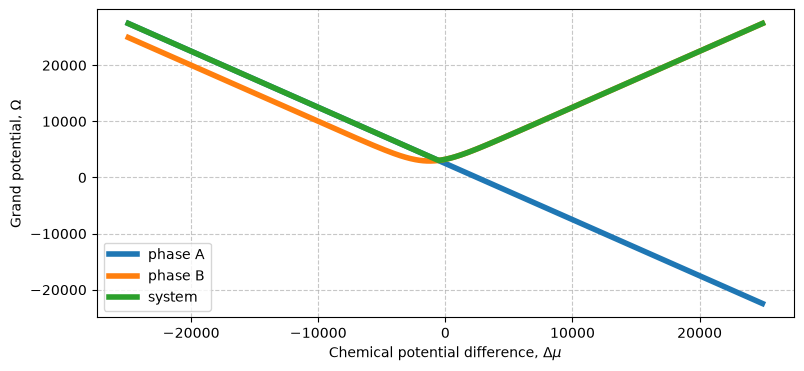

In [8]:
import matplotlib.pyplot as plt


# 3. Plot
plt.figure(figsize=(9, 4))

y_vals = phaseAb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phase A',  linewidth=4)

y_vals = phaseBb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='phase B', linewidth=4)

y_vals = systemb(input_tensor).detach().cpu().numpy().squeeze()
x_vals = input_tensor[..., 1].detach().cpu().numpy().squeeze() # Extracting the first feature column
plt.plot(x_vals, y_vals, label='system', linewidth=4)

plt.xlabel("Chemical potential difference, $\Delta \mu$")
plt.ylabel("Grand potential, $\Omega$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Free energy plot

In [9]:
fcns = legendre_transform([phaseA, phaseB, system], [1,2])
fA, fB, fsys = finalize(fcns, compile_graph=False)

fAd, muAd = fA(input_tensor)

fBd, muBd = fB(input_tensor)

fsysd, musysd = fsys(input_tensor)

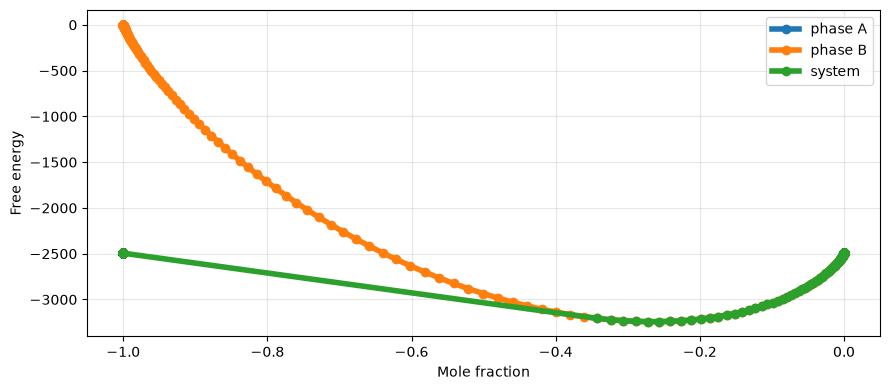

In [10]:

plt.figure(figsize=(9, 4))
plt.plot(muAd[:,1].detach(), -fAd.detach(), label=r'phase A', linewidth=4, marker='o', markersize=6)
plt.plot(muBd[:,1].detach(), -fBd.detach(), label=r'phase B', linewidth=4, marker='o', markersize=6)
plt.plot(musysd[:,1].detach(), -fsysd.detach(), label=r'system', linewidth=4, marker='o', markersize=6)


plt.xlabel(r'Mole fraction')
plt.ylabel(r'Free energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()